In [24]:
# Date Feature Engineering
import pandas as pd

# Load Dataset
df = pd.read_csv("data/q3_retail_promotions.csv")

# Convert to datetime
df["transaction_date"] = pd.to_datetime(df["transaction_date"])


# Extract Features
df["year"] = df["transaction_date"].dt.year
df["month"] = df["transaction_date"].dt.month
df["day_of_week"] = df["transaction_date"].dt.dayofweek

# Create is_month_end
df["is_month_end"] =(df["transaction_date"].dt.day >=25).astype(int)

#Display sample
print("Sample Data with new Features:")
df.head()

Sample Data with new Features:


,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold,year,month,day_of_week,is_month_end
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224,2022,1,5,0
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348,2022,1,5,0
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249,2022,1,6,0
3,2022-01-02,17,small,urban,free_gift,1,0,7,259,2022,1,6,0
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277,2022,1,0,0


In [25]:
# Temporal Train-Test Split
df = df.sort_values("transaction_date")

# Split index
split_index = int(len(df) * 0.8)

train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]

# Separate x and y
X_train = train_df.drop("items_sold", axis=1)
y_train = train_df["items_sold"]

X_test = test_df.drop("items_sold", axis=1)
y_test = test_df["items_sold"]

print("Training size:" ,train_df.shape)
print("Testing size: " , test_df.shape)

Training size: (960, 13)
Testing size:  (240, 13)


### Why random split is inappropriate

The dataset was sorted based on transaction_date and then split into training and testing sets.
  . Training set size = 960 records

  . Testing Set size = 240 records

In time-series or time-ordered data, future observations should not influence past data.

A random split may mix past and future records, causing data leakage and overly optimistic performance.

A temporal split ensures the model is trained on past data and tested on future data, which reflects real-world scenarios.

In [6]:
# 3. Preprocessing Pipeline

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Define Columns
categorical_cols = ["promotion_type", "location_type", "store_size"]
numerical_cols = [
    "store_id", "is_weekend", "is_festival",
    "competition_density", "year", "month",
    "day_of_week", "is_month_end"
]

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", StandardScaler(), numerical_cols)
    ]
)

In [12]:
# 4. Model Training and Evaluation
#Linear Regression Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
from sklearn.pipeline import Pipeline

# Pipeline
lr_pipeline = Pipeline([
     ("preprocessing", preprocessor),
    ("model", LinearRegression())
])

# Train
lr_pipeline.fit(X_train, y_train)

# Predict
y_pred_lr = lr_pipeline.predict(X_test)

# Metrics
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)

print("Linear Regression RMSE:", rmse_lr)
print("Linear Regression MAE:", mae_lr)

Linear Regression RMSE: 27.121451164890622
Linear Regression MAE: 21.05292667458839


In [14]:
# Random Forest Pipeline
from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", RandomForestRegressor(n_estimators=100, random_state=42))
])

# Train
rf_pipeline.fit(X_train, y_train)

# Predict
y_pred_rf = rf_pipeline.predict(X_test)

# Metrics
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print("Random Forest RMSE:", rmse_rf)
print("Random Forest MAE:", mae_rf)


Random Forest RMSE: 30.82130293455053
Random Forest MAE: 24.138125


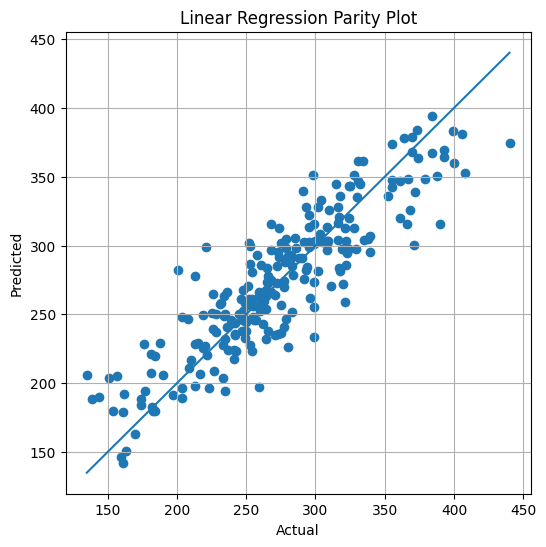

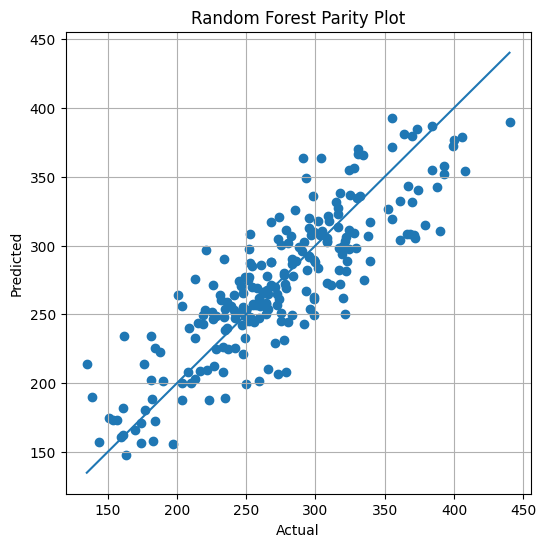

In [18]:
# Parity Plot
import matplotlib.pyplot as plt

def parity_plot(y_true, y_pred, title):
    plt.figure(figsize=(6,6))
    plt.scatter(y_true, y_pred)
    
    # Diagonal line
    plt.plot([y_true.min(), y_true.max()],
             [y_true.min(), y_true.max()])
    
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(title)
    plt.grid(True)
    plt.show()

# Plots
parity_plot(y_test, y_pred_lr, "Linear Regression Parity Plot")
parity_plot(y_test, y_pred_rf, "Random Forest Parity Plot")


In [22]:
# Get feature names after encoding
print("Feature importance from Random Forest:")
ohe = rf_pipeline.named_steps["preprocessing"].named_transformers_["cat"]
encoded_features = ohe.get_feature_names_out(categorical_cols)

all_features = list(encoded_features) + numerical_cols

# Feature importance
importances = rf_pipeline.named_steps["model"].feature_importances_

feat_imp_df = pd.DataFrame({
    "feature": all_features,
    "importance": importances
}).sort_values(by="importance", ascending=False)

# Top 5 features
feat_imp_df.head(5)

Feature importance from Random Forest:


,feature,importance
10,store_size_small,0.173360
13,is_festival,0.173027
7,location_type_urban,0.111915
17,day_of_week,0.086417
12,is_weekend,0.063369


*** Model Evaluation ***

Both Linear Regression And Random Foresr were trained and evaluated using RMSE and MAE.

. Linear Regression Performance:
   . RMSE : 27.12
   . MAE : 21.05

. Random Forest Performance:
   . RMSE : 30.82
   . MAE : 24.13

. From the results, Linear Regression perfroms better than Random Forest because it has lower RMSE and its predictions are closer to actual values on average.

*** FEATURE IMPORTANCE  ***
. store_size_small
. is_festival
. location_type_urban
. day_of_week
. is_weekend